In [1]:
# Machine Learning Algorithms
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression

# Used to split dataset into training and testing data
from sklearn.model_selection import train_test_split

# Used to evaluate classification models
from sklearn.metrics import accuracy_score, confusion_matrix

# Converts text columns into numerical values
from sklearn.preprocessing import LabelEncoder

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Part A: Understanding the Dataset 

## Q1. Dataset Overview : Load the dataset and answer the following: 

### How many rows and columns are present? 

In [3]:
df = pd.read_csv("agriculture_yield_dataset.csv")

In [4]:
df.shape

(1500, 8)

### What are the names of all columns? 

In [5]:
df.columns

Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare'],
      dtype='object')

### Display the first 10 records. 

In [6]:
df.head(10)

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


## Q2. Data Types and Missing Values 

### Check the data type of each column. 

In [7]:
df.dtypes

rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

### Identify whether any missing values are present.

In [8]:
df.isnull().sum()

rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64

In [9]:
df.isnull().any()

rainfall_mm              False
temperature_c            False
fertilizer_kg            False
irrigation_hours         False
soil_ph                  False
crop_type                False
soil_type                False
yield_ton_per_hectare    False
dtype: bool

### If missing values exist, mention the affected columns.

In [10]:
# no missing values are present

## Q3. Descriptive Statistics : Generate summary statistics for all numerical features and answer: 

In [11]:
df.describe()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,754.054667,27.749467,148.744067,5.403267,6.759133,5.028793
std,255.097216,5.758101,56.990279,2.584329,0.719742,0.968282
min,300.200000,18.000000,50.300000,1.000000,5.500000,2.090000
25%,536.175000,22.600000,98.600000,3.200000,6.100000,4.337500
50%,761.200000,27.700000,146.850000,5.400000,6.800000,5.010000
75%,964.375000,32.600000,196.575000,7.600000,7.400000,5.740000
max,1200.000000,38.000000,249.900000,10.000000,8.000000,7.860000


### Which feature has the highest mean value? 

In [12]:
df.describe().loc["mean"].idxmax()

'rainfall_mm'

### Which feature has the highest standard deviation? 

In [13]:
df.describe().loc["std"].idxmax()

'rainfall_mm'

# Part B: Exploratory Data Analysis (EDA) 

## Q4. Distribution Analysis : Create histograms for: 

### rainfall_mm

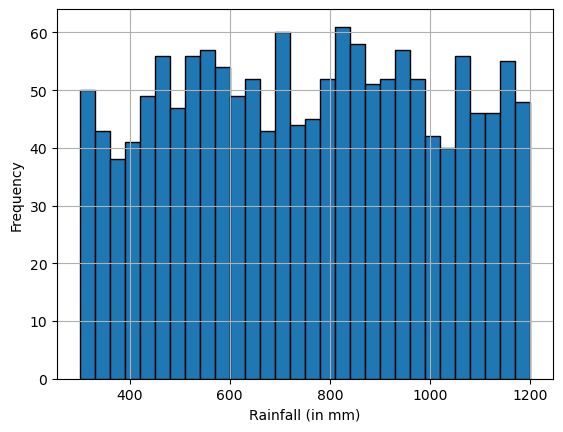

In [14]:
rainfall_data = df["rainfall_mm"]
plt.hist(rainfall_data, edgecolor="black", bins=30)
plt.xlabel("Rainfall (in mm)")
plt.ylabel("Frequency")
plt.grid()
plt.show()

### temperature_c

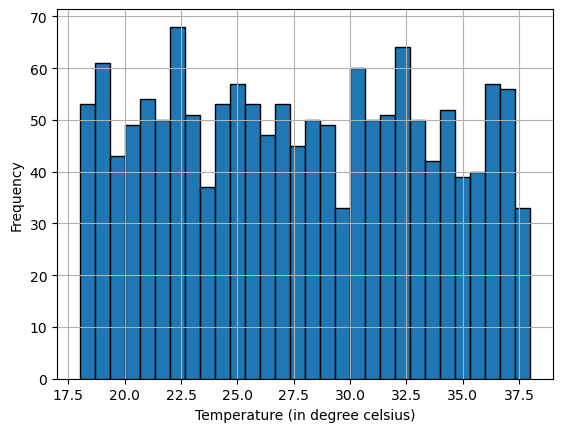

In [15]:
temp_data = df["temperature_c"]
plt.hist(temp_data, edgecolor="black", bins=30)
plt.xlabel("Temperature (in degree celsius)")
plt.ylabel("Frequency")
plt.grid()
plt.show()

### fertilizer_kg 

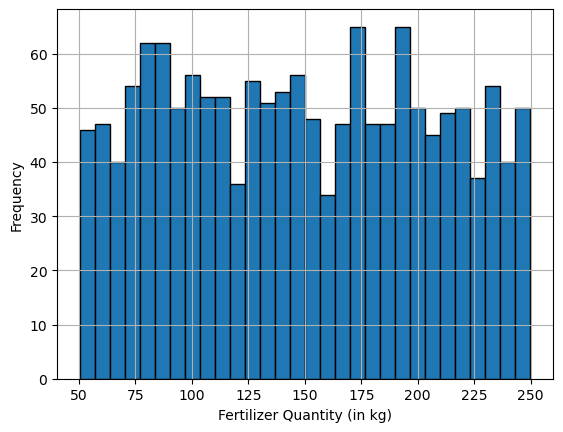

In [16]:
fertilizer_data = df["fertilizer_kg"]
plt.hist(fertilizer_data, edgecolor="black", bins=30)
plt.xlabel("Fertilizer Quantity (in kg)")
plt.ylabel("Frequency")
plt.grid()
plt.show()

### yield_ton_per_hectare

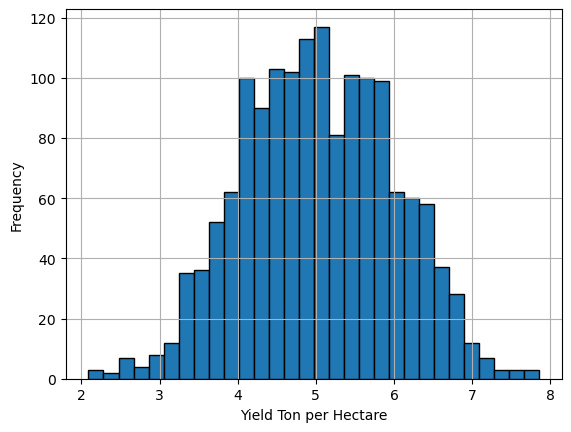

In [17]:
yield_data = df["yield_ton_per_hectare"]
plt.hist(yield_data, edgecolor="black", bins=30)
plt.xlabel("Yield Ton per Hectare")
plt.ylabel("Frequency")
plt.grid()
plt.show()

## Q5. Crop Type Analysis

### Find the number of records for each crop type.

In [18]:
df.columns

Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare'],
      dtype='object')

In [19]:
df.groupby("crop_type")["crop_type"].count()

crop_type
Cotton     311
Maize      287
Rice       293
Soybean    306
Wheat      303
Name: crop_type, dtype: int64

## Create a count plot (bar chart) for crop_type. 

C:\Users\kashv\AppData\Local\Temp\ipykernel_4900\2263332464.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(crop_type[i], crop_type_cnt.iloc[i]+5, str(crop_type_cnt[i]), ha="center")


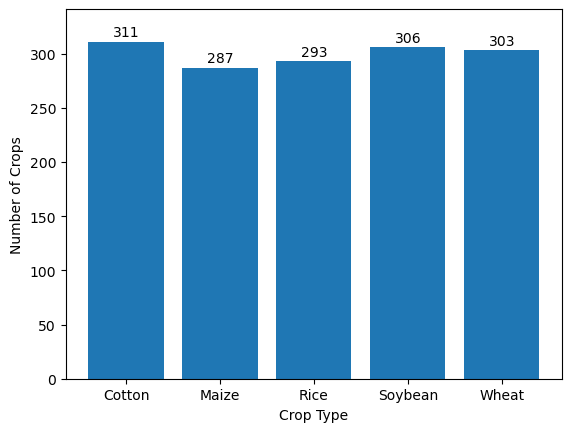

In [20]:
crop_type_cnt = df.groupby("crop_type")["crop_type"].count()
crop_type = crop_type_cnt.index
plt.bar(crop_type, crop_type_cnt)
plt.xlabel("Crop Type")
plt.ylabel("Number of Crops")
for i in range(len(crop_type_cnt)):
    plt.text(crop_type[i], crop_type_cnt.iloc[i]+5, str(crop_type_cnt[i]), ha="center")

plt.ylim(0,max(crop_type_cnt)+30)
plt.show()

### Which crop appears most frequently? 

In [21]:
crop_type_cnt.idxmax()

'Cotton'

## Q6. Soil Type Analysis 

### Find the frequency of each soil type.

In [22]:
df.columns

Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare'],
      dtype='object')

In [23]:
soil_type_cnt = df.groupby("soil_type")["soil_type"].count()
print(soil_type_cnt)

soil_type
Clay     534
Loamy    474
Sandy    492
Name: soil_type, dtype: int64


C:\Users\kashv\AppData\Local\Temp\ipykernel_4900\2904728619.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(soil_type[i], soil_type_cnt.iloc[i]+10, str(soil_type_cnt[i]), ha="center")


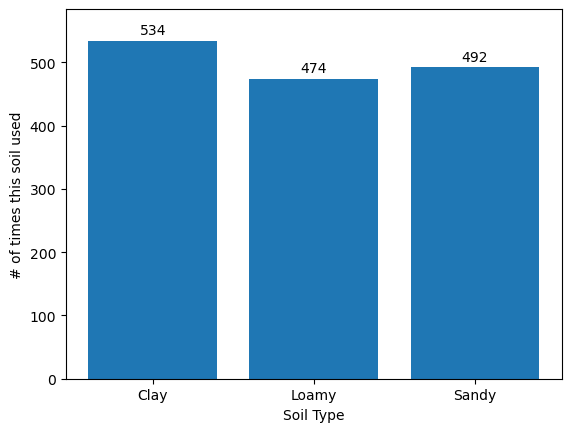

In [24]:
soil_type = soil_type_cnt.index
plt.bar(soil_type, soil_type_cnt)
plt.xlabel("Soil Type")
plt.ylabel("# of times this soil used")
for i in range(len(soil_type)):
    plt.text(soil_type[i], soil_type_cnt.iloc[i]+10, str(soil_type_cnt[i]), ha="center")

plt.ylim(0,max(soil_type_cnt)+50)
plt.show()

### Which soil type is most common? 

In [25]:
soil_type_cnt.idxmax()

'Clay'

## Q7. Yield Distribution : Create a histogram of yield_ton_per_hectare.

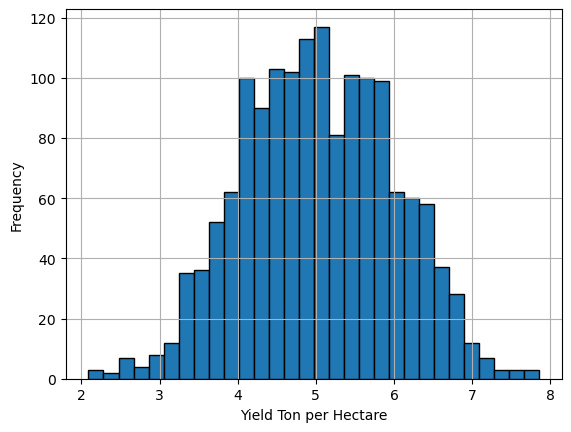

In [26]:
yield_data = df["yield_ton_per_hectare"]
plt.hist(yield_data, edgecolor="black", bins=30)
plt.xlabel("Yield Ton per Hectare")
plt.ylabel("Frequency")
plt.grid()
plt.show()

### Is the distribution approximately normal? 

In [27]:
# Yes

### Are there any noticeable outliers? 

In [28]:
# No, there are no noticeable or extreme outliers visible in the histogram, 
# as the data is tightly contained within the $2$ to $8$ range without any isolated bars.

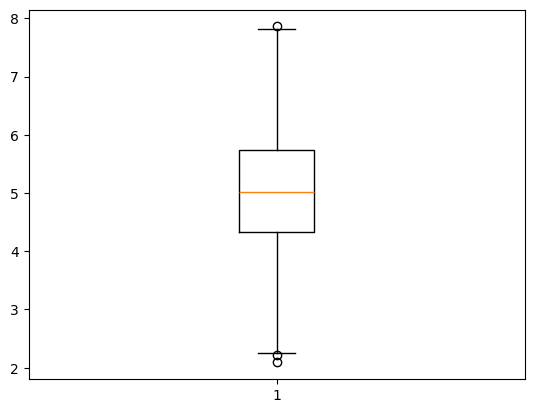

In [29]:
plt.boxplot(yield_data)
plt.show()

# but by looking at the boxplot we can definately detect that there are outliers, one is just below 8 (around 7.8)
# other two are just above 2 (around 2.1 and 2.3)

## Q8. Scatter Plot Analysis : Create scatter plots of: 

### 1. rainfall_mm vs yield_ton_per_hectare

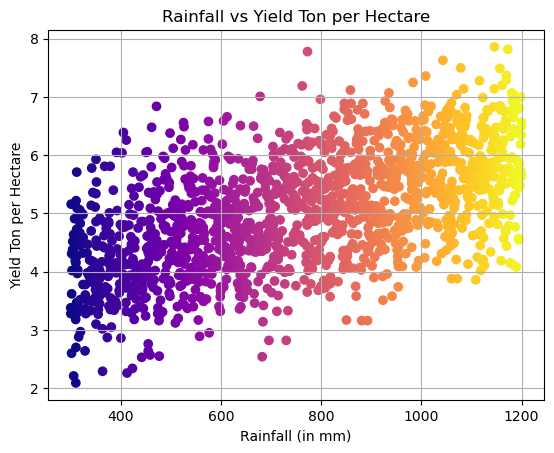

In [30]:
plt.scatter(rainfall_data, yield_data, cmap="plasma", c=rainfall_data)
plt.xlabel("Rainfall (in mm)")
plt.ylabel("Yield Ton per Hectare")
plt.title("Rainfall vs Yield Ton per Hectare")
plt.grid()
plt.show()

### 2. fertilizer_kg vs yield_ton_per_hectare

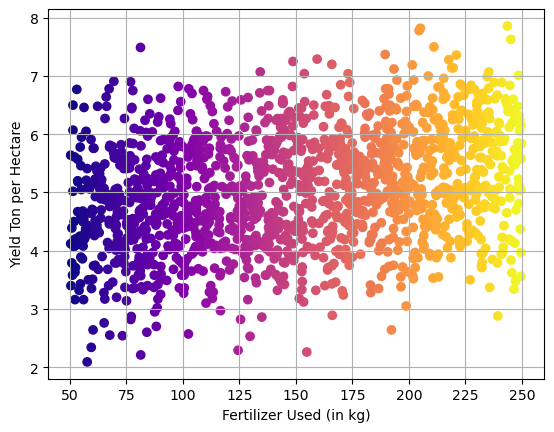

In [31]:
plt.scatter(fertilizer_data, yield_data, cmap="plasma", c=fertilizer_data)
plt.xlabel("Fertilizer Used (in kg)")
plt.ylabel("Yield Ton per Hectare")
plt.grid()
plt.show()

### Based on the plots: Which feature appears to have a stronger relationship with yield? 

In [32]:
# Rainfall has a stronger relationship with yield as one can cleary see the upward trend in the scatter plot,
# as rainfall increases, yield also increases
# whereas it is almost constant in case of fertilizers

## Q9. Correlation Analysis

### Generate a correlation matrix for numerical features.

In [33]:
numerical_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numerical_df.corr()
print(corr_matrix)

                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412               1.000000 

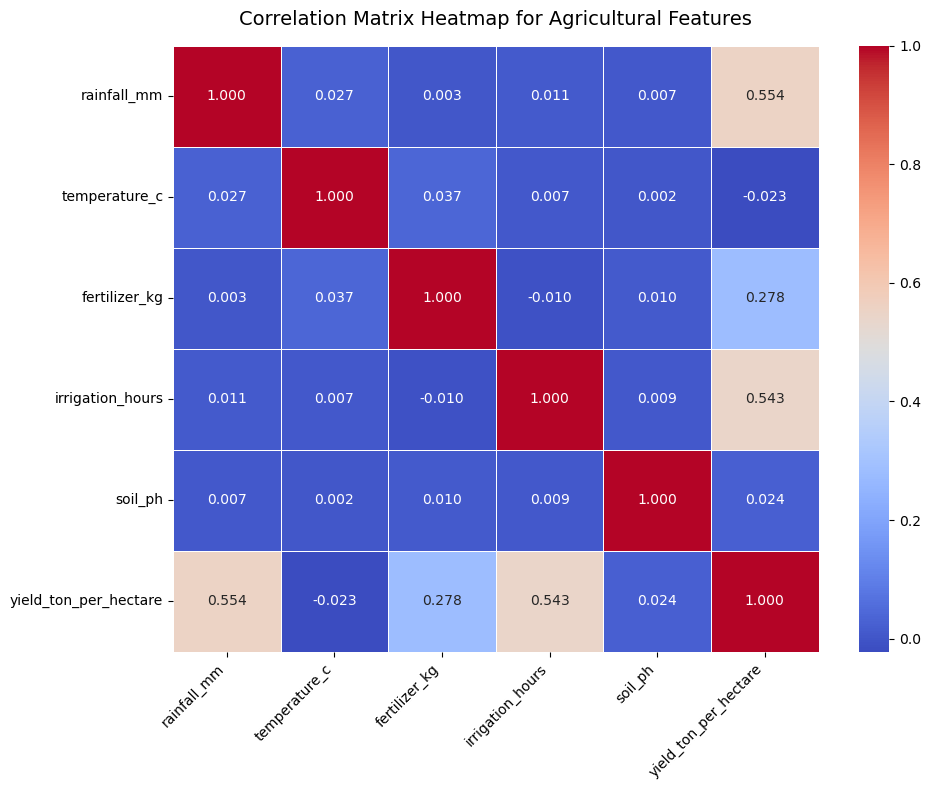

In [34]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".3f", 
    linewidths=0.5, 
    ax=ax, 
    cbar=True
)

ax.set_title('Correlation Matrix Heatmap for Agricultural Features', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

### Identify the top three features most correlated with crop yield. 

In [35]:
# Based on the correlation matrix, the top three numerical features most correlated with crop yield (yield_ton_per_hectare), ranked by the strength of their relationship, are:
# rainfall_mm (Rainfall) * Correlation Coefficient: 0.5537
# irrigation_hours (Irrigation Hours) * Correlation Coefficient: 0.5427
# fertilizer_kg (Fertilizer Amount) * Correlation Coefficient: 0.2780

## Q10. Group-Based Analysis 

### Calculate the average yield for: Each crop type  

In [36]:
crop_type_avg_yield = df.groupby("crop_type")["yield_ton_per_hectare"].mean()
print(crop_type_avg_yield)

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64


### Each soil type  

In [37]:
soil_type_avg_yield = df.groupby("soil_type")["yield_ton_per_hectare"].mean()
print(soil_type_avg_yield)

soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64


### Which crop and soil type have the highest average yield?

In [38]:
crop_type_avg_yield.idxmax()

'Rice'

In [39]:
soil_type_avg_yield.idxmax()

'Loamy'

# Part C: Data Preparation 

## Q11. Feature Encoding : The dataset contains categorical variables. 

### Identify the categorical columns.

In [40]:
df.select_dtypes(include=["object"]).columns

Index(['crop_type', 'soil_type'], dtype='object')

### Convert them into numerical form using One-Hot Encoding. 

In [41]:
df = pd.get_dummies(df, columns=["crop_type", "soil_type"], drop_first=True, dtype=int)

### Display the first five rows of the transformed dataset.

In [43]:
df.head()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,1,0,0,0,1,0
1,772.8,34.6,247.2,10.0,6.5,6.24,1,0,0,0,0,1
2,970.9,36.3,168.4,7.3,6.4,4.77,0,0,0,1,0,1
3,611.7,19.0,121.7,3.7,6.0,4.04,1,0,0,0,1,0
4,696.1,29.6,184.6,5.1,6.1,5.17,0,0,0,0,0,0


## Part C: Data Preparation

### Q12. Feature Selection 

In [52]:
# yield_ton_per_hectare is being used as target variable
X = df.drop(columns=["yield_ton_per_hectare"])
y = df["yield_ton_per_hectare"]

# Part D: Machine Learning

## Split the dataset into:  80% Training Data   20% Testing Data 

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=43)

## Display the shape of: 

### X_train

In [55]:
print(X_train.shape)

(1200, 11)


### X_test

In [56]:
print(X_test.shape)

(300, 11)


### y_train

In [57]:
print(y_train.shape)

(1200,)


### y_test

In [59]:
print(y_test.shape)

(300,)


## Q14. Linear Regression Model 

### Train a Linear Regression model.  

In [60]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [64]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test,y_pred)
r2

0.8377430936992643

### Display the model coefficients and intercept. 

In [73]:
print(model.intercept_)
model_coefficients = pd.DataFrame({
    "columns" : X.columns,
    "coefficients" : model.coef_
})
model_coefficients

1.5354414361727846


,columns,coefficients
0,rainfall_mm,0.002034
1,temperature_c,-0.009167
2,fertilizer_kg,0.004946
3,irrigation_hours,0.200216
4,soil_ph,0.007369
5,crop_type_Maize,0.270597
6,crop_type_Rice,0.889921
7,crop_type_Soybean,0.508465
8,crop_type_Wheat,0.374805
9,soil_type_Loamy,0.315947


### Which feature has the highest positive coefficient? 

In [83]:
model_coefficients.iloc[model_coefficients["coefficients"].idxmax()]

columns         crop_type_Rice
coefficients          0.889921
Name: 6, dtype: object